### Extracting the Principal Components Step by Step

Let's start by doing the first 4 steps of PCA:
- Standardizing the data
- Constructing the covariance matrix
- Obtaining the eigenvalues and eigenvectors of the covariance matrix
- Sorting the eigenvalues by decreasing order to rank the eigenvectors

In [1]:
import pandas as pd
df_wine = pd.read_csv('wine.data', header=None)
df_wine.columns = ['Class label', 'Alcohol',
                   'Malic acid', 'Ash', 
                   'Alcalinity of ash', 'Magnesium', 
                   'Total phenols', 'Flavanoids',
                   'Nonflavanoid phenols', 
                   'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 
                   'Proline']

from sklearn.model_selection import train_test_split
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y,
                                                    random_state=0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

The first step is complete, now we need to construct the covariance matrix. This d by d-dimensional matrix stores the pairwise covariances between the different features. A positive covariance means the two features increase or decrease together, whereas a negative covariance indicates that the features vary in opposite directions. The eigenvectors of the covariance matrix represent the principal components(the directions of maximum variance) and the corresponding eigenvalues will define their magnitude.

We will use linalg.eig function from Numpy to obtain eigenpairs of the Wine covariance matrix:

In [2]:
import numpy as np
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
print('\nEigenvalues \n', eigen_vals)



Eigenvalues 
 [4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]


### Total and Explained Variance

Let's now calculate the cumulative sum of the explained variances and plot it:

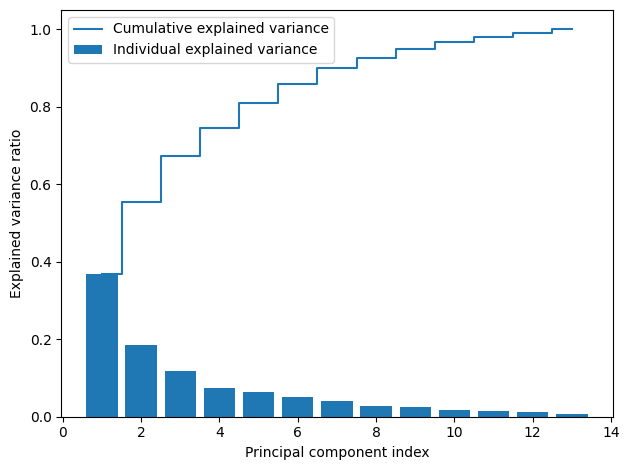

In [3]:
tot = sum(eigen_vals)
var_exp = [(i/tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

import matplotlib.pyplot as plt
plt.bar(range(1, 14), var_exp, align='center', label='Individual explained variance')
plt.step(range(1, 14), cum_var_exp, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

The plot indicates that the first principal component alone accounts for approximately 40 percent of the variance, and the first two principal components combined account for almost 60 percent of the variance in the dataset.

### Feature Transformation

Now that we have decomposed the covariance matrix into eigenpairs, let's proceed with the remaining 3 steps:
- Select k largest eigenvectors
- Construct a projection matrix $\mathbf{W}$ from the top k eigenvectors
- Transform the d-dimensional input data using the projection matrix $\mathbf{W}$ to obtain the new k-dimensional feature subspace

In [4]:
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

Let's collect the first two eigenvectors to capture 60% of the variance in the dataset:

In [5]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))

print('Matrix W:\n', w)

Matrix W:
 [[-0.13724218  0.50303478]
 [ 0.24724326  0.16487119]
 [-0.02545159  0.24456476]
 [ 0.20694508 -0.11352904]
 [-0.15436582  0.28974518]
 [-0.39376952  0.05080104]
 [-0.41735106 -0.02287338]
 [ 0.30572896  0.09048885]
 [-0.30668347  0.00835233]
 [ 0.07554066  0.54977581]
 [-0.32613263 -0.20716433]
 [-0.36861022 -0.24902536]
 [-0.29669651  0.38022942]]


Using the projection matrix, we can transform an example row vector (13-dimensional), onto the PCA subspace (the principal components one and two). We can also transform the entire 124 $\times$ 13-dimensional training dataset onto the two principal components by calculating the matrix dot product:

In [6]:
X_train_std[0].dot(w)
X_train_pca = X_train_std.dot(w)

Using two principal components allows us to visualize the transformed Wine training dataset easily:

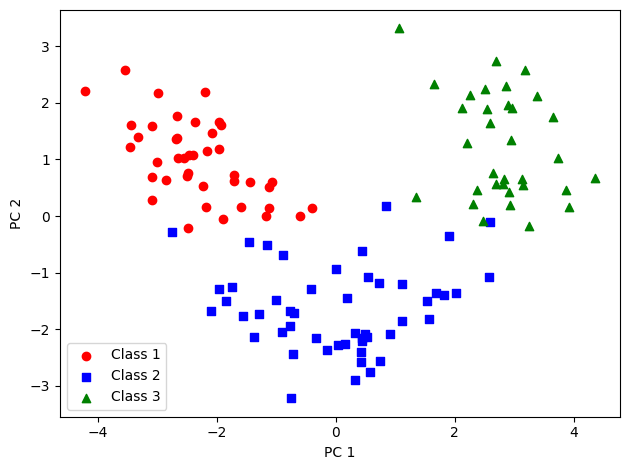

In [7]:
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']
for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                c=c, marker=m, label=f'Class {l}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

As we can see, the data is more spread along the first principal component than the second principal component, which is consistent with the explained variance ratio plot that we created in the previous subsection. However, we can tell that a linear classifier will likely be able to separate the classes well.

### Principal Component Analysis in scikit-learn

We will now go through the scikit-learn implementation of the PCA class. Let's start with bringing back our decision region plotting function from Chapter 2:

In [8]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    """
    Plot 2D decision regions for a trained classifier.

    Parameters
    ----------
    X : array-like of shape (n_samples, 2)
        Feature matrix with exactly 2 columns.
    y : array-like of shape (n_samples,)
        Class labels.
    classifier : object
        Trained model with a .predict() method.
    resolution : float
        Step size for the background grid.
    """

    # Visual style for each class
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    unique_classes = np.unique(y)
    cmap = ListedColormap(colors[:len(unique_classes)])

    # Determine plot boundaries from the data
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    # Create a dense grid of coordinates covering the whole plot area
    x_values = np.arange(x_min, x_max, resolution)
    y_values = np.arange(y_min, y_max, resolution)
    grid_x, grid_y = np.meshgrid(x_values, y_values)

    # Convert the grid into a list of points:
    # [[x1, y1], [x2, y2], [x3, y3], ...]
    grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

    # Predict a class for every point in the grid
    grid_predictions = classifier.predict(grid_points)

    # Turn the 1D predictions back into the 2D grid shape
    decision_map = grid_predictions.reshape(grid_x.shape)

    # Draw the colored decision regions
    plt.contourf(grid_x, grid_y, decision_map, alpha=0.3, cmap=cmap)
    plt.xlim(grid_x.min(), grid_x.max())
    plt.ylim(grid_y.min(), grid_y.max())

    # Plot the actual data points on top
    for class_index, class_label in enumerate(unique_classes):
        plt.scatter(
            X[y == class_label, 0],
            X[y == class_label, 1],
            alpha=0.8,
            c=colors[class_index],
            marker=markers[class_index],
            label=f"Class {class_label}",
            edgecolor="black"
        )


Now, let's use the PCA class from scikit-learn on the Wine training dataset, classify the transformed examples via logistic regression, and visualize the decision regions via the plot_decision_regions function:

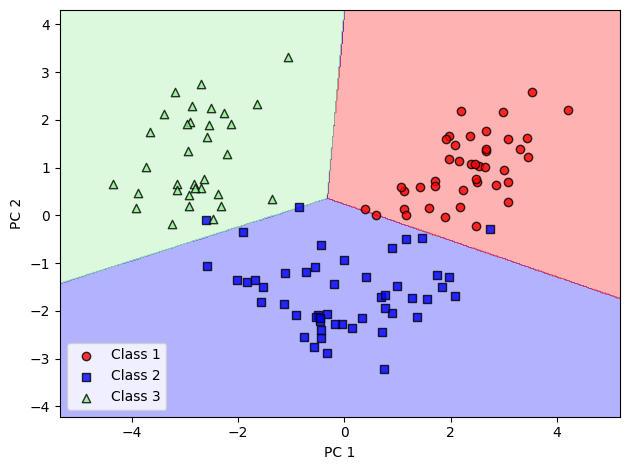

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
lr = OneVsRestClassifier(LogisticRegression(solver='lbfgs', 
                                            random_state=1))

X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

lr.fit(X_train_pca, y_train)
plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Let's also plot the decision regions for the test dataset for completeness:

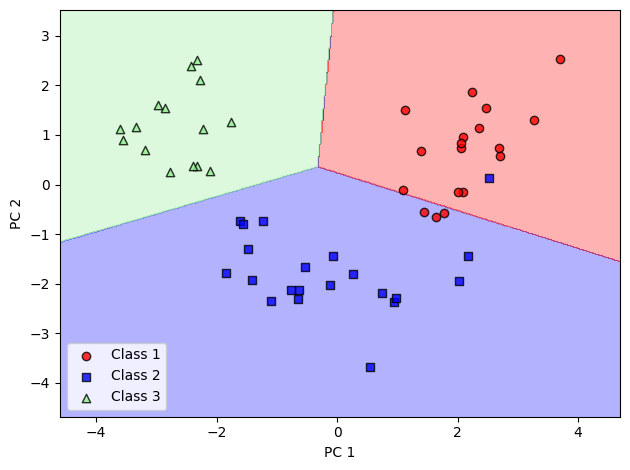

In [10]:
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Assessing Feature Contributions

Let's compute the 13 $\times$ 13 dimensional loadings matrix by multiplying the eigenvectors by the square root of the eigenvalues:

In [11]:
loadings = eigen_vecs * np.sqrt(eigen_vals)

Then, we can plot the loadings for the first principal component, which is the first column in this matrix:

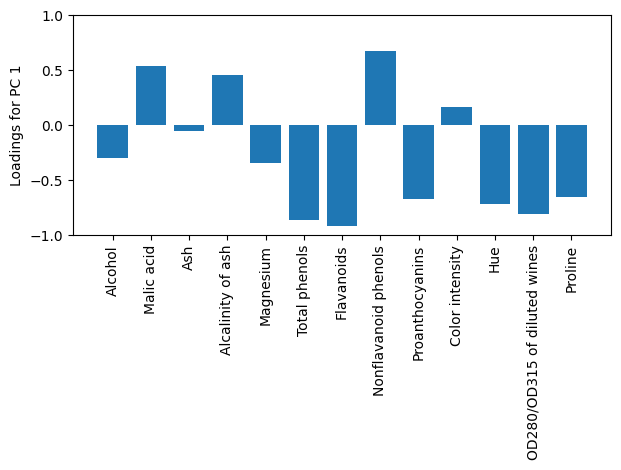

In [12]:
fig, ax = plt.subplots()
ax.bar(range(13), loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

We can see that alcohol has a negative correlation with the first principal component whereas malic acid has a positive correlation. These factor loadings were for our own PCA implementation, we can obtain the loadings form a fitted scikit-learn PCA object in a similar way:

In [13]:
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

Let us recreate the bar plot using these loadings now:

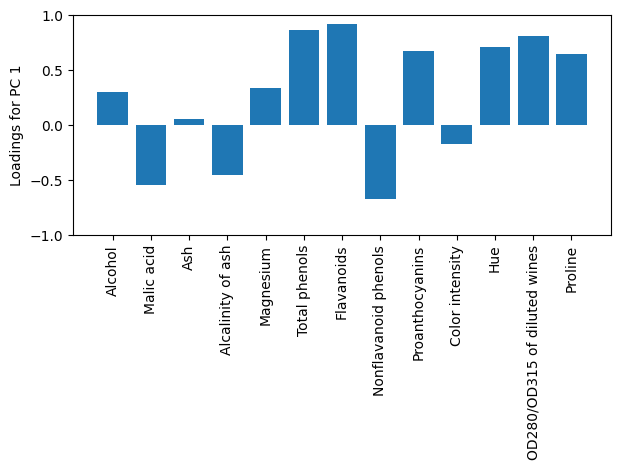

In [14]:
fig, ax = plt.subplots()
ax.bar(range(13), sklearn_loadings[:, 0], align='center')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
ax.set_ylabel('Loadings for PC 1')
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

### Supervised Data Compression via Linear Discriminant Analysis

Let's implement LDA now, starting with the calculation of the mean vectors, which we will use to construct the within class and the between-class scatter matrices. Each mean vector $\mathbf{m}_i$ stores the mean feature values with respect to the examples of class i.

In [15]:
np.set_printoptions(precision=4)
mean_vecs = []
for label in range(1, 4):
    mean_vecs.append(np.mean(X_train_std[y_train == label], axis=0))
    print(f'MV {label}: {mean_vecs[label -1]}\n')

MV 1: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 2: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]

MV 3: [ 0.1992  0.866   0.1682  0.4148 -0.0451 -1.0286 -1.2876  0.8287 -0.7795
  0.9649 -1.209  -1.3622 -0.4013]



Using mean vectors, we can now compute the within-class scatter matrix $\mathbf{S}_W$:

In [16]:
d = 13 # number of features
S_W = np.zeros((d,d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.zeros((d, d))
    for row in X_train_std[y_train == label]:
        row, mv = row.reshape(d, 1), mv.reshape(d, 1)
        class_scatter += (row - mv).dot((row - mv).T)
    S_W += class_scatter

The assumption that we are making when we are computing the scatter matrices is that the class labels in the training dataset are uniformly distributed. However, our classes have different numbers of examples, so this assumption is violated. We would need to scale the individual scatter matrices by the number of class examples, essentially computing the covariance matrices:

In [17]:
d = 13
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.cov(X_train_std[y_train == label].T)
    S_W += class_scatter

Now, we can compute the between-class sactter matrix $\mathbf{S}_B$

In [18]:
mean_overall = np.mean(X_train_std, axis = 0)
mean_overall = mean_overall.reshape(d, 1)

d = 13
S_B = np.zeros((d, d))
for i, mean_vec in enumerate(mean_vecs):
    n = X_train_std[y_train == i + 1, :].shape[0]
    mean_vec = mean_vec.reshape(d, 1)
    S_B += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)

### Selecting Linear Discriminants for the New Feature Subspace

The remaining steps are similar to PCA. However, instead of performing the eigendecomposition of the covariance matrix, we solve the generalized eigenvalue problem of the matrix $\mathbf{S}^{-1}_{W}\mathbf{S}_B$

In [19]:
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

After we compute the eigenpairs, we can sort the eigenvalues in descending order:

In [20]:
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]
eigen_pairs = sorted(eigen_pairs, key=lambda x: x[0], reverse=True)
print('Eigenvalues in descending order:\n')
for eigen_val, _ in eigen_pairs:
    print(eigen_val)

Eigenvalues in descending order:

349.61780890599397
172.7615221897938
3.2778759481604224e-14
2.842170943040401e-14
2.6347620763320892e-14
2.6347620763320892e-14
1.7169492680170284e-14
1.7169492680170284e-14
1.674335053365994e-14
1.2740060380615559e-14
7.458378098449663e-15
4.7370485570543226e-15
3.6888431873149695e-15


To measure how much of the class discriminatory information is captured by the linear discriminants (eigenvectors), let's plot the linear discriminants by decreasing eigenvalues, similar to the explained variance plot for PCA:

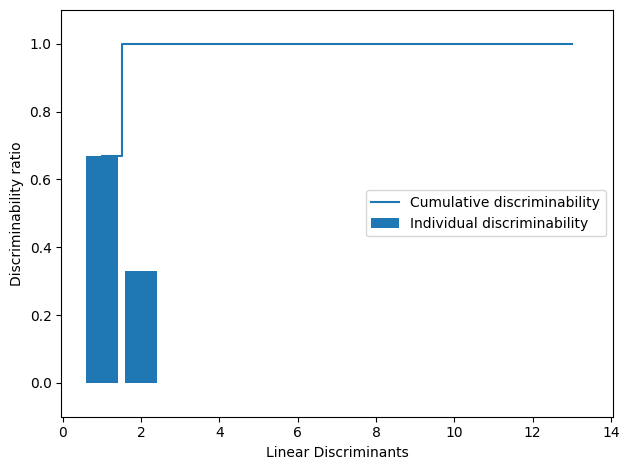

In [21]:
tot = sum(eigen_vals.real)
discr = [(i / tot) for i in sorted(eigen_vals.real, reverse=True)]
cum_discr = np.cumsum(discr)
plt.bar(range(1, 14), discr, align='center', label='Individual discriminability')
plt.step(range(1, 14), cum_discr, where='mid', label='Cumulative discriminability')
plt.xlabel('Linear Discriminants')
plt.ylabel('Discriminability ratio')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.tight_layout()
plt.show()

As we can see, the first two linear discriminants capture 100 percent of the useful information of the training dataset. Let's now stack the two most discriminative eigenvector columns to create the transformation matrix: 

In [22]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis].real,
               eigen_pairs[1][1][:, np.newaxis].real))

print('Matrix W:\n', w)

Matrix W:
 [[-0.1481 -0.4092]
 [ 0.0908 -0.1577]
 [-0.0168 -0.3537]
 [ 0.1484  0.3223]
 [-0.0163 -0.0817]
 [ 0.1913  0.0842]
 [-0.7338  0.2823]
 [-0.075  -0.0102]
 [ 0.0018  0.0907]
 [ 0.294  -0.2152]
 [-0.0328  0.2747]
 [-0.3547 -0.0124]
 [-0.3915 -0.5958]]


### Projecting Examples onto the New Feature Space

Now that we have the transformation matrix $\mathbf{W}$, we can transform our dataset by multiplying it with the training dataset:

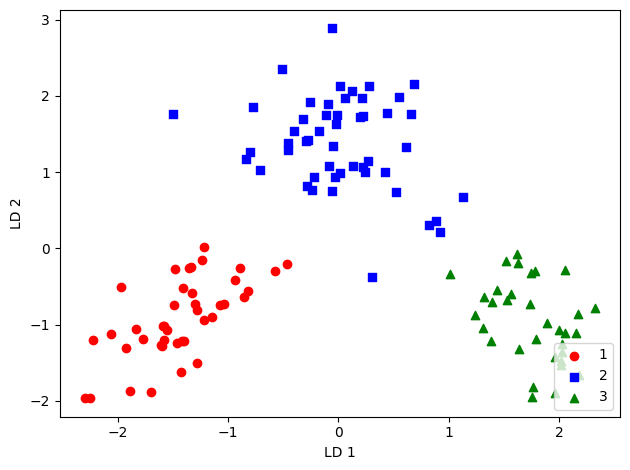

In [23]:
X_train_lda = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train==l, 0],
                X_train_lda[y_train==l, 1],
                c=c, label=l, marker=m)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### LDA via scikit-learn

Let's now see how the LDA implementation of scikit-learn behaves:

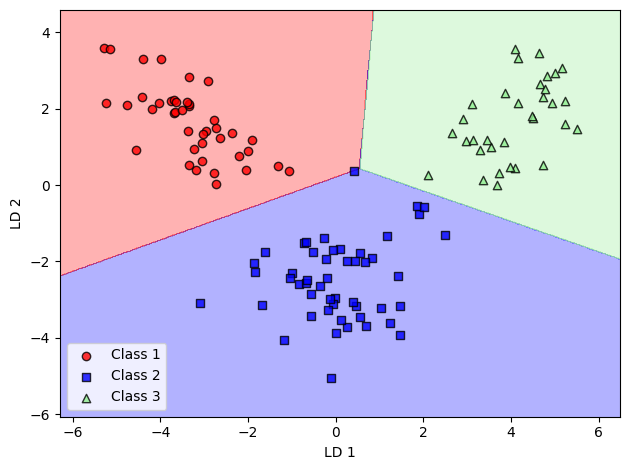

In [24]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)

lr = OneVsRestClassifier(LogisticRegression(solver='lbfgs',
                                            random_state=1))
lr = lr.fit(X_train_lda, y_train)
plot_decision_regions(X_train_lda, y_train, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Visualizing Data via t-distributed Stochastic Neighbor Embedding

Let's also demonstrate t-SNE, a nonlinear dimension reduction technique, using the 64-dimensional digits dataset that contains low-resolution images of handwritten digits:

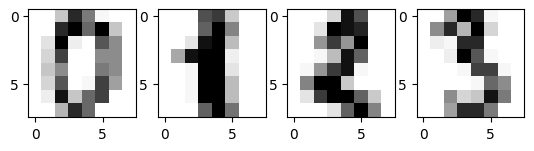

In [25]:
from sklearn.datasets import load_digits
digits = load_digits()

fig, ax = plt.subplots(1, 4)
for i in range(4):
    ax[i].imshow(digits.images[i], cmap='Greys')
plt.show()


Let's assign the features (pixels) and target (digit) from the dataset into variables that we can work with, then use the t-SNE class to transform the data:

In [26]:
from sklearn.manifold import TSNE

X_digits = digits.data
y_digits = digits.target

tsne = TSNE(n_components=2, init='pca', random_state=123)
X_digits_tsne = tsne.fit_transform(X_digits)

We have projected the 64 dimensional data onto a 2 dimensional space. Specifying init='pca' is recommended. Note that t-SNE includes other hyperparameters like perplexity and learning rate which we omitted. Let's now visualize the 2D t-SNE embeddings:

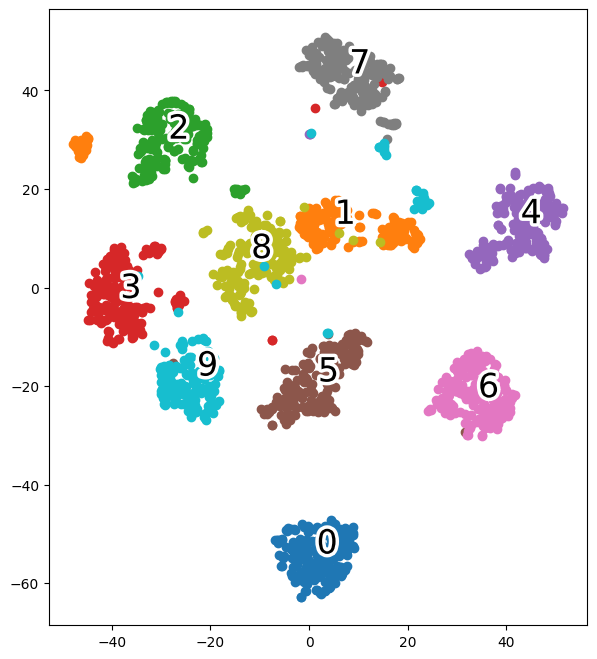

In [27]:
import matplotlib.patheffects as PathEffects

def plot_projection(x, colors):
    
    f = plt.figure(figsize=(8, 8))
    ax = plt.subplot(aspect='equal')
    for i in range(10):
        plt.scatter(x[colors == i, 0],
                    x[colors == i, 1])
    
    for i in range(10):
        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([PathEffects.Stroke(linewidth=5, foreground="w"),
                              PathEffects.Normal()])
    

plot_projection(X_digits_tsne, y_digits)
plt.show()


Like PCA, t-SNE is an unsupervised method, and we used the class labels only for visualization purposes via the function's color argument. the median function is used to display the labels in the middle of the center of the data points for each digit. t-SNE was able to separate the classes nicely, but not perfectly. 